<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit8/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pymc-bart
!pip install -q "preliz[full,notebook]"
!pip install -q bambi
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv
import pymc_bart as pmb

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is like a flowchart that is used for classification and regression tasks by breaking down complex decisions into a series of smaller, binary (yes or no) choices.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of a decision tree is the length of the longest path from the root node to a leaf node.

Depth controls the complexity: shallow trees risk underfitting (missing patterns), while deep trees risk overfitting (memorizing noise).

**Task4:**

How are BART models similar and different from a decision tree?

Both use decision tree structures. However, BART uses Bayesian inference to average over sum-of-trees models or a group of many smaller trees.

**Task5**:

Why would we use a BART model instead of a decision tree?

BART is more preferred because it tends to work well with complex nonlinear relationships while also sort of avoiding overfitting. It works well with more variables put simply.

## Bartian Penguins

In [ ]:
!pip install pymc-bart
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import graphviz as gv

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [ ]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
pingu_noot_noot = pd.read_csv(url).dropna()

In [ ]:
X = pingu_noot_noot[["flipper_length", "bill_depth", "bill_length"]]

Y = pingu_noot_noot["body_mass"].values

In [ ]:
with pm.Model() as model_penguins:
  mu = pmb.BART("mu", X, Y, m=25)

  sigma = pm.HalfNormal("sigma", sigma=1)
  y_c = pm.Normal("y_c", mu=mu, sigma=sigma, observed=y)

  idata_pingu_noot_noot = pm.sample()

  pm.sample_posterior_predictive(idata_pingu_noot_noot, extend_inferencedata=True)

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [ ]:
posterior_mean = idata_pingu_noot_noot.posterior["mu"]

μ_hdi = az.hdi(ary=idata_pingu_noot_noot, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_pingu_noot_noot, group="posterior_predictive", var_names=["y_c"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


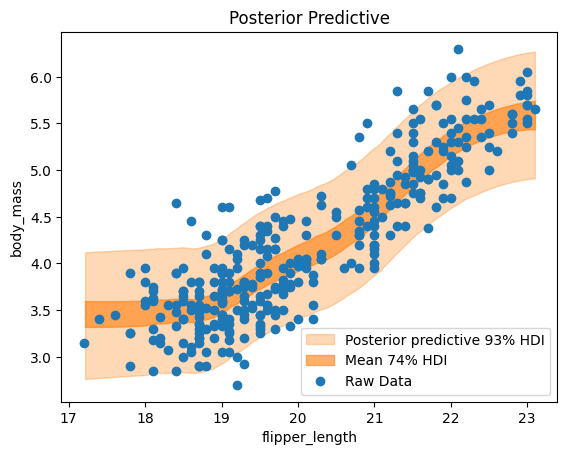

In [ ]:
idx = np.argsort(X.to_numpy()[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive 93% HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean 74% HDI"},
)
ax.plot(pingu_noot_noot['flipper_length'], pingu_noot_noot["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

It looks good because as the flipper length increases, the body mass increases as well. And if you look at the HDI you can see that it actually follows this general trend pretty closely. It kind of seems like clusters that sort of line up.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

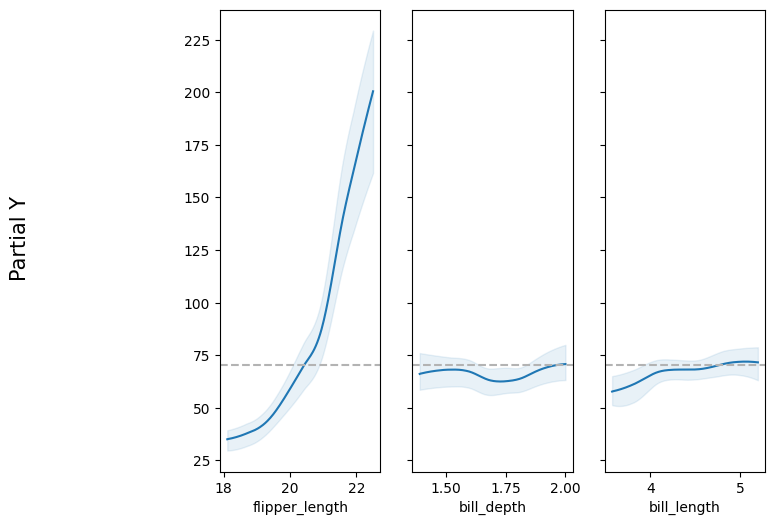

In [ ]:
pmb.plot_pdp(mu, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

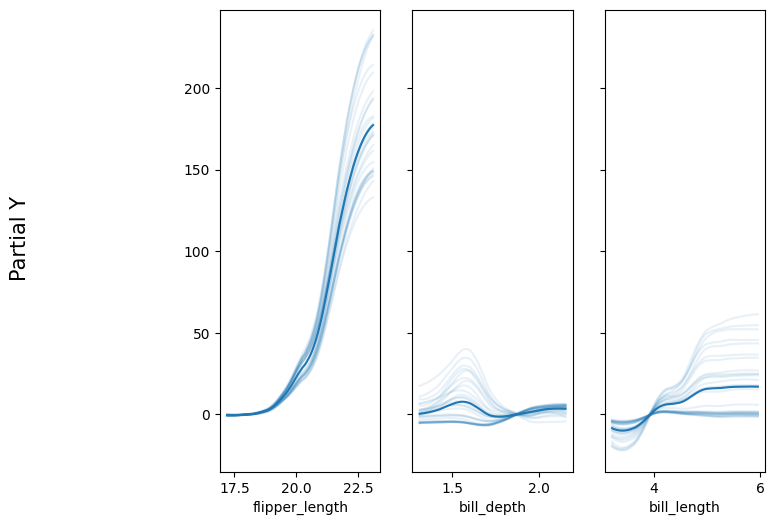

In [ ]:
pmb.plot_ice(mu, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [ ]:
var_imp_penguins = pmb.compute_variable_importance(idata_pingu_noot_noot, mu, X)

<Axes: ylabel='R²'>

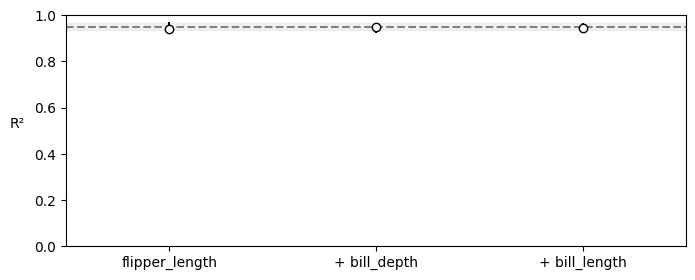

In [ ]:
pmb.plot_variable_importance(var_imp_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Flipper length, in my opinion, looks to be the most important variable. Bill length and bill depth don't help to improve the value (R^2). It also has more correlation.